# Market State Dynamic Regression LDS for Group Ensemble (No Log)

In this notebook, we implement a state-space regression model for movie revenue prediction with latent market dynamics over years. The main idea is that movie revenue is not only driven by observed movie-specific features, but also by broader market conditions that may change over time. To account for this, the model combines a latent yearly market state with time-varying regression coefficients for selected predictors.

The model is built so that some feature effects are allowed to change over time, while others are kept fixed across years. This gives a regression model that is flexible enough to capture gradual temporal shifts, while still keeping a relatively simple observation structure.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoNormal
from pyro.optim import Adam

pyro.set_rng_seed(42)
torch.set_default_dtype(torch.float32)


In [2]:
TRAIN_PATH = '../data/movies_with_genres_and_cast_train.csv'
TEST_PATH = '../data/movies_with_genres_and_cast_test.csv'
EXPORT_PATH = '../data/market_state_dynamic_regression_lds_group_nolog_predictions.csv'

GENRE_COLUMNS = [
    'genre_drama',
    'genre_comedy',
    'genre_thriller',
    'genre_romance',
    'genre_action',
    'genre_horror',
    'genre_crime',
    'genre_documentary',
    'genre_adventure',
    'genre_science_fiction',
    'other_genre',
]

train_df = pd.read_csv(TRAIN_PATH).copy()
test_df = pd.read_csv(TEST_PATH).copy()

for frame in (train_df, test_df):
    frame['release_date'] = pd.to_datetime(frame['release_date'])
    frame['year'] = frame['year'].astype(int)
    frame['budget_missing_base'] = frame['budget_inflated'] <= 0
    frame['dominant_genre'] = frame[GENRE_COLUMNS].idxmax(axis=1)

train_df['is_train'] = True
test_df['is_train'] = False
full_df = pd.concat([train_df, test_df], ignore_index=True).copy()

full_df['revenue_deflator_raw'] = np.where(full_df['revenue'] > 0, full_df['revenue_inflated'] / full_df['revenue'], np.nan)
full_df['budget_deflator_raw'] = np.where(full_df['budget'] > 0, full_df['budget_inflated'] / full_df['budget'], np.nan)
year_to_deflator = {}
for year, group in full_df.groupby("year", sort=True):
    rev_median = group['revenue_deflator_raw'].median()
    bud_median = group['budget_deflator_raw'].median()
    if pd.notna(rev_median):
        year_to_deflator[int(year)] = float(rev_median)
    elif pd.notna(bud_median):
        year_to_deflator[int(year)] = float(bud_median)
    else:
        raise ValueError(f"No inflation factor could be derived for year {year}")

full_df['inflation_factor'] = full_df['year'].map(year_to_deflator).astype(float)
train_df = full_df[full_df["is_train"]].copy()
test_df = full_df[~full_df["is_train"]].copy()

print('train shape:', train_df.shape)
print('test shape :', test_df.shape)
print('train years:', int(train_df['year'].min()), '-', int(train_df['year'].max()))
print('test years :', int(test_df['year'].min()), '-', int(test_df['year'].max()))
print('train row order preserved:', np.array_equal(train_df['id'].to_numpy(), pd.read_csv(TRAIN_PATH)['id'].to_numpy()))
print('test row order preserved :', np.array_equal(test_df['id'].to_numpy(), pd.read_csv(TEST_PATH)['id'].to_numpy()))
print('missing budgets train:', int(train_df['budget_missing_base'].sum()))
print('missing budgets test :', int(test_df['budget_missing_base'].sum()))

train_df.head()


train shape: (4199, 41)
test shape : (2846, 41)
train years: 1970 - 2007
test years : 2008 - 2017
train row order preserved: True
test row order preserved : True
missing budgets train: 1185
missing budgets test : 778


,budget,id,popularity,release_date,revenue,runtime,vote_average,vote_count,doy,year,...,month_sin,month_cos,log_revenue_inflated,log_budget_inflated,budget_missing_base,dominant_genre,is_train,revenue_deflator_raw,budget_deflator_raw,inflation_factor
0,0.0,42587.0,0.005351,1970-01-01,25.0,92.0,7.1,5.0,1.0,1970,...,0.5,0.866025,5.312976,0.000000,True,genre_documentary,True,8.078131,NaN,8.078131
1,3500000.0,651.0,7.701349,1970-01-24,81600000.0,116.0,6.9,238.0,24.0,1970,...,0.5,0.866025,20.306500,17.157434,False,genre_drama,True,8.078131,8.078131,8.078131
2,12000000.0,11202.0,14.382289,1970-01-25,89800000.0,172.0,7.3,327.0,25.0,1970,...,0.5,0.866025,20.402256,18.389578,False,genre_drama,True,8.078131,8.078131,8.078131
3,25485000.0,11165.0,7.262326,1970-01-26,29548291.0,144.0,6.9,150.0,26.0,1970,...,0.5,0.866025,19.290697,19.142761,False,genre_drama,True,8.078131,8.078131,8.078131
4,11000000.0,42345.0,2.272580,1970-01-27,2200000.0,124.0,5.9,16.0,27.0,1970,...,0.5,0.866025,16.693129,18.302566,False,genre_drama,True,8.078131,8.078131,8.078131


## Data Setup

We use the shared group split directly from the tracked CSV files, so the notebook works on the same training and test rows that are used in the final aggregation workflow.

The model uses years as the internal time index. This means that the latent variables evolve one year at a time, even though the observations themselves are individual movies. Each movie $n$ is assigned a release-year index $t_n$, which links that movie to the latent state and coefficient vector for its year.

We also preserve the original row order from the test file, since this matters when predictions from several models are combined later.


## Preprocessing

The observed predictors are split into two groups. The dynamic predictors, denoted by $\mathbf{x}_n$, are the features whose effects are allowed to vary over time. In the implementation, these are the standardized budget and the genre indicator variables. The static predictors, denoted by $\mathbf{z}_n$, are the features whose coefficients are shared across all years. In the implementation, these are month sine/cosine terms, a budget-missing indicator, and standardized runtime.

A main preprocessing choice is how we handle movies with `budget_inflated <= 0`. We treat these budgets as missing rather than as true zero-budget films. The handling is the same `Impute+Flag` strategy used earlier:

- detect missing budgets from `budget_inflated <= 0`
- impute `budget_inflated` using **training data only**
- use fallback order: same year + dominant genre, then same year, then global train median
- add a binary `budget_missing` indicator as an extra static feature

We also include `runtime` as an additional static feature. Runtime is imputed on the raw scale using training data only and then standardized from training statistics only, in the same spirit as the budget preprocessing.

After imputation, we standardize the inflation-adjusted budget feature, runtime, and the internal target using training-set statistics only. This is mainly done for numerical stability during inference.


In [3]:
BASE_STATIC_COLUMNS = ['month_sin', 'month_cos']
TARGET_COLUMN = 'revenue_inflated'


def impute_budget(row, year_genre_medians, year_medians, global_median):
    key = (int(row['year']), row['dominant_genre'])
    if key in year_genre_medians:
        return year_genre_medians[key], 'year_genre'

    year = int(row['year'])
    if year in year_medians:
        return year_medians[year], 'year'

    return global_median, 'global'


train_valid_budget = train_df[~train_df['budget_missing_base']].copy()
global_budget_median = float(train_valid_budget['budget_inflated'].median())
year_budget_medians = train_valid_budget.groupby('year')['budget_inflated'].median().to_dict()
year_genre_budget_medians = train_valid_budget.groupby(['year', 'dominant_genre'])['budget_inflated'].median().to_dict()

full_df['budget_missing'] = 0
full_df['budget_imputation_strategy'] = 'observed'

fallback_counts = {'year_genre': 0, 'year': 0, 'global': 0}
missing_mask = full_df['budget_missing_base']
imputed_values = []
imputation_labels = []

for _, row in full_df.loc[missing_mask].iterrows():
    value, label = impute_budget(row, year_genre_budget_medians, year_budget_medians, global_budget_median)
    imputed_values.append(value)
    imputation_labels.append(label)
    fallback_counts[label] += 1

full_df.loc[missing_mask, 'budget_inflated'] = imputed_values
full_df.loc[missing_mask, 'budget_missing'] = 1
full_df.loc[missing_mask, 'budget_imputation_strategy'] = imputation_labels

train_df = full_df[full_df["is_train"]].copy()
test_df = full_df[~full_df["is_train"]].copy()

for frame in (full_df, train_df, test_df):
    frame['runtime_missing_base'] = frame['runtime'].isna() | (frame['runtime'] <= 0)

train_valid_runtime = train_df[~train_df['runtime_missing_base']].copy()
global_runtime_median = float(train_valid_runtime['runtime'].median())
runtime_missing_mask = full_df['runtime_missing_base']
full_df.loc[runtime_missing_mask, 'runtime'] = global_runtime_median

train_df = full_df[full_df["is_train"]].copy()
test_df = full_df[~full_df["is_train"]].copy()

DYNAMIC_COLUMNS = ['budget_inflated_std', *GENRE_COLUMNS]
STATIC_COLUMNS = [*BASE_STATIC_COLUMNS, 'budget_missing', 'runtime_std']

budget_mean = train_df['budget_inflated'].mean()
budget_std = train_df['budget_inflated'].std()
if budget_std == 0:
    budget_std = 1.0

y_mean = train_df[TARGET_COLUMN].mean()
y_std = train_df[TARGET_COLUMN].std()
if y_std == 0:
    y_std = 1.0

runtime_mean = train_df['runtime'].mean()
runtime_std = train_df['runtime'].std()
if runtime_std == 0:
    runtime_std = 1.0

for frame in (full_df, train_df, test_df):
    frame['budget_inflated_std'] = (frame['budget_inflated'] - budget_mean) / budget_std
    frame['runtime_std'] = (frame['runtime'] - runtime_mean) / runtime_std
    frame['y_std'] = (frame[TARGET_COLUMN] - y_mean) / y_std

years = np.arange(int(full_df["year"].min()), int(full_df["year"].max()) + 1)
year_to_idx = {year: idx for idx, year in enumerate(years)}

X_dyn_full_np = full_df[DYNAMIC_COLUMNS].to_numpy()
X_static_full_np = full_df[STATIC_COLUMNS].to_numpy()
y_full_std_np = full_df["y_std"].to_numpy()
year_idx_full_np = full_df["year"].map(year_to_idx).to_numpy()
obs_mask_np = full_df["is_train"].to_numpy().astype(bool)
test_mask_np = ~obs_mask_np
inflation_factor_full_np = full_df["inflation_factor"].to_numpy(dtype=float)

X_dyn_full = torch.tensor(X_dyn_full_np, dtype=torch.float32)
X_static_full = torch.tensor(X_static_full_np, dtype=torch.float32)
y_full_std = torch.tensor(y_full_std_np, dtype=torch.float32)
year_idx_full = torch.tensor(year_idx_full_np, dtype=torch.long)
obs_mask = torch.tensor(obs_mask_np, dtype=torch.bool)

print('imputation fallback counts:', fallback_counts)
print('full horizon years:', int(years[0]), '-', int(years[-1]), '(', len(years), 'years )')
print('dynamic coefficient dimension:', X_dyn_full_np.shape[1])
print('static coefficient dimension :', X_static_full_np.shape[1])
print('global budget median (train raw inflated scale):', round(global_budget_median, 4))
print('runtime imputed rows:', int(runtime_missing_mask.sum()))
print('global runtime median (train raw scale):', round(global_runtime_median, 4))


imputation fallback counts: {'year_genre': 1150, 'year': 35, 'global': 778}
full horizon years: 1970 - 2017 ( 48 years )
dynamic coefficient dimension: 12
static coefficient dimension : 4
global budget median (train raw inflated scale): 38895838.9903
runtime imputed rows: 27
global runtime median (train raw scale): 103.0


## Baselines and Metrics

We keep two simple baselines for reference:

- a **mean baseline**, which predicts the training-set mean for every movie
- a **static regression baseline**, which uses the same observed features but no temporal dynamics

The notebook reports two kinds of metrics:

- **inflation-adjusted revenue metrics** for internal LDS diagnostics
- **nominal revenue metrics** for comparison with the other group models

The second set is the important one for aggregation and report comparison. Since the runtime-enabled variants performed best in the ablation study, runtime is now part of the comparison here as well.


In [4]:
def evaluate_inflated_predictions(y_true_inflated, y_pred_inflated, label):
    y_true_inflated = np.asarray(y_true_inflated)
    y_pred_inflated = np.asarray(y_pred_inflated)

    rmse_inflated = np.sqrt(np.mean((y_true_inflated - y_pred_inflated) ** 2))
    mae_inflated = np.mean(np.abs(y_true_inflated - y_pred_inflated))
    ss_res = np.sum((y_true_inflated - y_pred_inflated) ** 2)
    ss_tot = np.sum((y_true_inflated - y_true_inflated.mean()) ** 2)
    r2_inflated = 1.0 - ss_res / ss_tot

    metrics = {
        'rmse_inflated': rmse_inflated,
        'mae_inflated': mae_inflated,
        'r2_inflated': r2_inflated,
    }

    print(label)
    for key, value in metrics.items():
        print(f'  {key}: {value:.4f}')
    return metrics


def evaluate_revenue_predictions(y_true_revenue, y_pred_revenue, label):
    y_true_revenue = np.asarray(y_true_revenue)
    y_pred_revenue = np.asarray(y_pred_revenue)

    rmse = np.sqrt(np.mean((y_true_revenue - y_pred_revenue) ** 2))
    mae = np.mean(np.abs(y_true_revenue - y_pred_revenue))
    ss_res = np.sum((y_true_revenue - y_pred_revenue) ** 2)
    ss_tot = np.sum((y_true_revenue - y_true_revenue.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot

    metrics = {
        'rmse_revenue': rmse,
        'mae_revenue': mae,
        'r2_revenue': r2,
    }

    print(label)
    for key, value in metrics.items():
        print(f'  {key}: {value:.4f}')
    return metrics


train_true_revenue = train_df["revenue"].to_numpy()
test_true_revenue = test_df["revenue"].to_numpy()
train_inflation_factor = train_df["inflation_factor"].to_numpy()
test_inflation_factor = test_df["inflation_factor"].to_numpy()

mean_train_pred_inflated = np.full(len(train_df), y_mean)
mean_test_pred_inflated = np.full(len(test_df), y_mean)
mean_train_pred_revenue = mean_train_pred_inflated / train_inflation_factor
mean_test_pred_revenue = mean_test_pred_inflated / test_inflation_factor

mean_train_log_metrics = evaluate_inflated_predictions(train_df[TARGET_COLUMN], mean_train_pred_inflated, 'Mean baseline on train (inflation-adjusted revenue scale)')
mean_test_log_metrics = evaluate_inflated_predictions(test_df[TARGET_COLUMN], mean_test_pred_inflated, 'Mean baseline on test (inflation-adjusted revenue scale)')
mean_train_revenue_metrics = evaluate_revenue_predictions(train_true_revenue, mean_train_pred_revenue, 'Mean baseline on train (nominal revenue)')
mean_test_revenue_metrics = evaluate_revenue_predictions(test_true_revenue, mean_test_pred_revenue, 'Mean baseline on test (nominal revenue)')


X_baseline_train = np.column_stack([np.ones(len(train_df)), train_df[DYNAMIC_COLUMNS].to_numpy(), train_df[STATIC_COLUMNS].to_numpy()])
X_baseline_test = np.column_stack([np.ones(len(test_df)), test_df[DYNAMIC_COLUMNS].to_numpy(), test_df[STATIC_COLUMNS].to_numpy()])

baseline_coef, *_ = np.linalg.lstsq(X_baseline_train, train_df['y_std'].to_numpy(), rcond=None)

baseline_train_pred_std = X_baseline_train @ baseline_coef
baseline_test_pred_std = X_baseline_test @ baseline_coef

baseline_train_pred_inflated = baseline_train_pred_std * y_std + y_mean
baseline_test_pred_inflated = baseline_test_pred_std * y_std + y_mean
baseline_train_pred_revenue = baseline_train_pred_inflated / train_inflation_factor
baseline_test_pred_revenue = baseline_test_pred_inflated / test_inflation_factor

baseline_train_log_metrics = evaluate_inflated_predictions(train_df[TARGET_COLUMN], baseline_train_pred_inflated, 'Static baseline on train (inflation-adjusted revenue scale)')
baseline_test_log_metrics = evaluate_inflated_predictions(test_df[TARGET_COLUMN], baseline_test_pred_inflated, 'Static baseline on test (inflation-adjusted revenue scale)')
baseline_train_revenue_metrics = evaluate_revenue_predictions(train_true_revenue, baseline_train_pred_revenue, 'Static baseline on train (nominal revenue)')
baseline_test_revenue_metrics = evaluate_revenue_predictions(test_true_revenue, baseline_test_pred_revenue, 'Static baseline on test (nominal revenue)')


Mean baseline on train (inflation-adjusted revenue scale)
  rmse_inflated: 246310983.9335
  mae_inflated: 141808880.6481
  r2_inflated: 0.0000
Mean baseline on test (inflation-adjusted revenue scale)
  rmse_inflated: 255949551.5306
  mae_inflated: 151180681.7241
  r2_inflated: -0.0026
Mean baseline on train (nominal revenue)
  rmse_revenue: 114848708.3824
  mae_revenue: 67665191.0284
  r2_revenue: 0.0136
Mean baseline on test (nominal revenue)
  rmse_revenue: 187297359.2395
  mae_revenue: 110465966.6497
  r2_revenue: -0.0008
Static baseline on train (inflation-adjusted revenue scale)
  rmse_inflated: 204304683.8165
  mae_inflated: 107089116.6674
  r2_inflated: 0.3120
Static baseline on test (inflation-adjusted revenue scale)
  rmse_inflated: 167155296.6270
  mae_inflated: 85714912.5120
  r2_inflated: 0.5724
Static baseline on train (nominal revenue)
  rmse_revenue: 87179551.7252
  mae_revenue: 49527409.6074
  r2_revenue: 0.4317
Static baseline on test (nominal revenue)
  rmse_revenue: 

## Model

The model is a market-state dynamic regression state-space model. For each year $t$, the model includes a latent scalar market state $m_t$ and a latent vector of regression coefficients $\boldsymbol{\beta}_t$. The market state is meant to capture the general market environment in a given year, while $\boldsymbol{\beta}_t$ captures how the effects of the dynamic predictors change over time.

For movie $n$, the expected standardized inflation-adjusted revenue is modeled as

$$
\mu_n = m_{t_n} + \mathbf{x}_n^\top \boldsymbol{\beta}_{t_n} + \mathbf{z}_n^\top \boldsymbol{\gamma},
$$

where $t_n$ is the release-year index, $\mathbf{x}_n$ contains the dynamic predictors, $\mathbf{z}_n$ contains the static predictors, and $\boldsymbol{\gamma}$ is the vector of static coefficients. The observed response is then modeled as

$$
y_n \sim \mathcal{N}(\mu_n,\sigma_y^2).
$$

This gives a regression structure where predictions depend both on observed movie features and on latent yearly market dynamics.

The yearly latent variables are modeled with mean-reverting first-order dynamics. This means that both the market state and the time-varying regression coefficients evolve gradually across years, while also being pulled back toward a long-run mean level.


In [5]:
def market_state_dynamic_regression_model(X_dyn, X_static, year_idx, num_years, y_obs=None, obs_mask=None):
    dynamic_dim = X_dyn.shape[1]
    static_dim = X_static.shape[1]

    static_beta = pyro.sample(
        'static_beta',
        dist.Normal(torch.zeros(static_dim), 0.5 * torch.ones(static_dim)).to_event(1),
    )

    market_mean = pyro.sample('market_mean', dist.Normal(torch.tensor(0.0), torch.tensor(0.5)))
    raw_market_rho = pyro.sample('raw_market_rho', dist.Normal(torch.tensor(2.0), torch.tensor(0.4)))
    market_rho = torch.sigmoid(raw_market_rho)
    market_scale = pyro.sample('market_scale', dist.LogNormal(torch.tensor(-2.7), torch.tensor(0.35)))

    beta_mean = pyro.sample(
        'beta_mean',
        dist.Normal(torch.zeros(dynamic_dim), 0.5 * torch.ones(dynamic_dim)).to_event(1),
    )
    raw_beta_rho = pyro.sample('raw_beta_rho', dist.Normal(torch.tensor(2.0), torch.tensor(0.4)))
    beta_rho = torch.sigmoid(raw_beta_rho)
    budget_scale = pyro.sample('budget_scale', dist.LogNormal(torch.tensor(-2.6), torch.tensor(0.35)))
    genre_scale = pyro.sample('genre_scale', dist.LogNormal(torch.tensor(-3.0), torch.tensor(0.35)))
    obs_scale = pyro.sample('obs_scale', dist.LogNormal(torch.tensor(-1.0), torch.tensor(0.4)))

    beta_transition_scale = torch.cat([
        budget_scale.unsqueeze(0),
        genre_scale.repeat(dynamic_dim - 1),
    ])

    market_prev = pyro.sample('market_0', dist.Normal(market_mean, torch.tensor(0.25)))
    beta_prev = pyro.sample('beta_0', dist.Normal(beta_mean, 0.25 * torch.ones(dynamic_dim)).to_event(1))

    market_states = [market_prev]
    beta_states = [beta_prev]

    for t in range(1, num_years):
        market_prev = pyro.sample(
            f'market_{t}',
            dist.Normal(market_mean + market_rho * (market_prev - market_mean), market_scale),
        )
        beta_prev = pyro.sample(
            f'beta_{t}',
            dist.Normal(beta_mean + beta_rho * (beta_prev - beta_mean), beta_transition_scale).to_event(1),
        )
        market_states.append(market_prev)
        beta_states.append(beta_prev)

    market_path = torch.stack(market_states)
    beta_path = torch.stack(beta_states)

    pyro.deterministic('market_path', market_path)
    pyro.deterministic('beta_path', beta_path)

    dynamic_part = (X_dyn * beta_path[year_idx]).sum(-1)
    static_part = X_static.matmul(static_beta)
    mean = market_path[year_idx] + dynamic_part + static_part
    pyro.deterministic('mean', mean)

    obs_dist = dist.Normal(mean, obs_scale)
    if obs_mask is not None:
        obs_dist = obs_dist.mask(obs_mask)

    with pyro.plate('movies', X_dyn.shape[0]):
        pyro.sample('obs', obs_dist, obs=y_obs)


def fit_model(num_steps=3500, lr=0.02):
    pyro.clear_param_store()
    guide = AutoNormal(market_state_dynamic_regression_model)
    svi = SVI(market_state_dynamic_regression_model, guide, Adam({'lr': lr}), loss=Trace_ELBO())

    losses = []
    for step in range(num_steps):
        loss = svi.step(X_dyn_full, X_static_full, year_idx_full, len(years), y_obs=y_full_std, obs_mask=obs_mask)
        losses.append(loss)
        if step % 500 == 0:
            print(f'step {step:4d}   loss = {loss:.2f}')
    return guide, losses


## Inference and Posterior Prediction

The implementation follows the model structure above, but with a few choices that are specific to this notebook. First, the response variable is standardized inflation-adjusted revenue, so the model is fit on a normalized target rather than raw revenue. Second, the budget coefficient is allowed to have its own transition scale, while all genre coefficients share a common transition scale. This makes the dynamic coefficient process more structured and avoids giving every coefficient a fully separate transition variance.

The model is implemented in Pyro. The global parameters, latent yearly states, and observation model are defined directly in the probabilistic model function, and posterior inference is done using stochastic variational inference with an `AutoNormal` guide. During training, only training-set observations contribute to the likelihood through an observation mask, while the full time horizon is still used for the latent yearly paths.

After fitting, we use `Predictive()` to draw posterior predictive samples for all rows. These samples are then summarized into predictive means and standard deviations, and they also make it possible to inspect the inferred market path and the time-varying regression coefficients over time.


In [6]:
guide, losses = fit_model()

predictive = Predictive(
    model=market_state_dynamic_regression_model,
    guide=guide,
    num_samples=300,
    return_sites=('obs', 'mean', 'market_path', 'beta_path', 'static_beta', 'market_mean', 'beta_mean'),
)

samples = predictive(X_dyn_full, X_static_full, year_idx_full, len(years), y_obs=None, obs_mask=None)

def squeeze_predictive_samples(array):
    array = np.asarray(array)
    while array.ndim >= 3 and array.shape[1] == 1:
        array = np.squeeze(array, axis=1)
    return array

obs_samples_std = squeeze_predictive_samples(samples['obs'].detach().cpu().numpy())
mean_samples_std = squeeze_predictive_samples(samples['mean'].detach().cpu().numpy())
market_path_samples = squeeze_predictive_samples(samples['market_path'].detach().cpu().numpy())
beta_path_samples = squeeze_predictive_samples(samples['beta_path'].detach().cpu().numpy())
static_beta_samples = squeeze_predictive_samples(samples['static_beta'].detach().cpu().numpy())

mean_pred_inflated = mean_samples_std.mean(axis=0) * y_std + y_mean
obs_samples_inflated = obs_samples_std * y_std + y_mean
mean_samples_inflated = mean_samples_std * y_std + y_mean
mean_samples_revenue = mean_samples_inflated / inflation_factor_full_np[None, :]

train_mean_pred_inflated = mean_pred_inflated[obs_mask_np]
test_mean_pred_inflated = mean_pred_inflated[test_mask_np]
train_revenue_samples = mean_samples_revenue[:, obs_mask_np]
test_revenue_samples = mean_samples_revenue[:, test_mask_np]
train_pred_revenue_mean = train_revenue_samples.mean(axis=0)
test_pred_revenue_mean = test_revenue_samples.mean(axis=0)
train_pred_revenue_std = train_revenue_samples.std(axis=0)
test_pred_revenue_std = test_revenue_samples.std(axis=0)

print('Posterior predictive samples:', obs_samples_std.shape[0])

market_train_log_metrics = evaluate_inflated_predictions(train_df[TARGET_COLUMN], train_mean_pred_inflated, 'Market-state LDS on train (inflation-adjusted revenue scale)')
market_test_log_metrics = evaluate_inflated_predictions(test_df[TARGET_COLUMN], test_mean_pred_inflated, 'Market-state LDS on test (inflation-adjusted revenue scale)')
market_train_revenue_metrics = evaluate_revenue_predictions(train_true_revenue, train_pred_revenue_mean, 'Market-state LDS on train (nominal revenue)')
market_test_revenue_metrics = evaluate_revenue_predictions(test_true_revenue, test_pred_revenue_mean, 'Market-state LDS on test (nominal revenue)')


step    0   loss = 7419.87
step  500   loss = 5243.48
step 1000   loss = 5251.02
step 1500   loss = 5246.46
step 2000   loss = 5267.78
step 2500   loss = 5244.20
step 3000   loss = 5237.59
Posterior predictive samples: 300
Market-state LDS on train (inflation-adjusted revenue scale)
  rmse_inflated: 194527927.8817
  mae_inflated: 104546791.7636
  r2_inflated: 0.3763
Market-state LDS on test (inflation-adjusted revenue scale)
  rmse_inflated: 164057035.2206
  mae_inflated: 87685136.3579
  r2_inflated: 0.5881
Market-state LDS on train (nominal revenue)
  rmse_revenue: 84527548.8119
  mae_revenue: 47761535.9501
  r2_revenue: 0.4657
Market-state LDS on test (nominal revenue)
  rmse_revenue: 119813115.7090
  mae_revenue: 64133689.2288
  r2_revenue: 0.5905


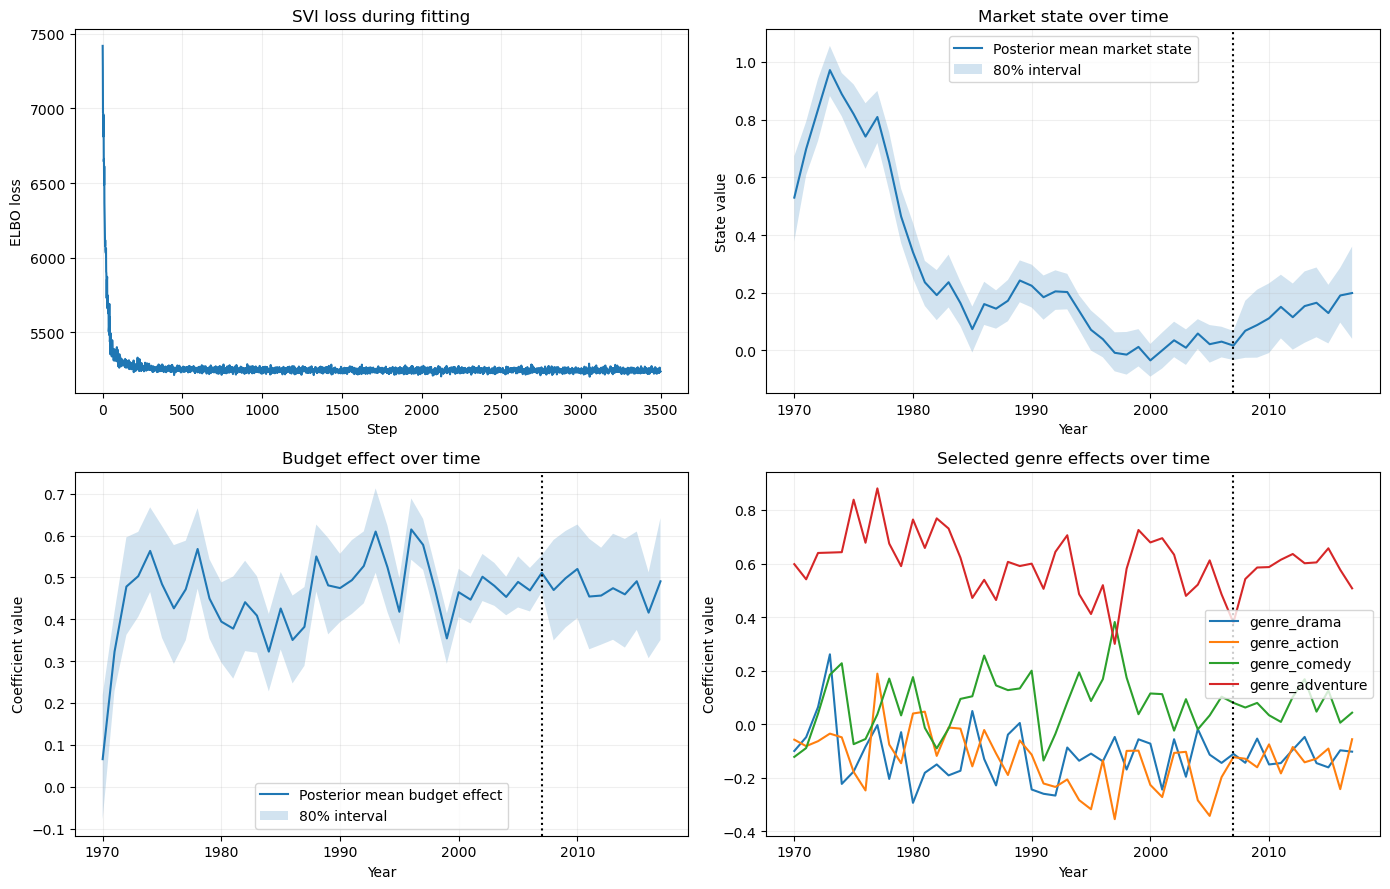

In [7]:
market_mean = market_path_samples.mean(axis=0)
market_low = np.quantile(market_path_samples, 0.1, axis=0)
market_high = np.quantile(market_path_samples, 0.9, axis=0)

beta_mean = beta_path_samples.mean(axis=0)
beta_low = np.quantile(beta_path_samples, 0.1, axis=0)
beta_high = np.quantile(beta_path_samples, 0.9, axis=0)

selected_genres = ['genre_drama', 'genre_action', 'genre_comedy', 'genre_adventure']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(losses)
axes[0, 0].set_title('SVI loss during fitting')
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('ELBO loss')

axes[0, 1].plot(years, market_mean, label='Posterior mean market state')
axes[0, 1].fill_between(years, market_low, market_high, alpha=0.2, label='80% interval')
axes[0, 1].axvline(train_df['year'].max(), color='black', linestyle=':')
axes[0, 1].set_title('Market state over time')
axes[0, 1].set_xlabel('Year')
axes[0, 1].legend()

budget_idx = DYNAMIC_COLUMNS.index('budget_inflated_std')
axes[1, 0].plot(years, beta_mean[:, budget_idx], label='Posterior mean budget effect')
axes[1, 0].fill_between(years, beta_low[:, budget_idx], beta_high[:, budget_idx], alpha=0.2, label='80% interval')
axes[1, 0].axvline(train_df['year'].max(), color='black', linestyle=':')
axes[1, 0].set_title('Budget effect over time')
axes[1, 0].set_xlabel('Year')
axes[1, 0].legend()

for name in selected_genres:
    idx = DYNAMIC_COLUMNS.index(name)
    axes[1, 1].plot(years, beta_mean[:, idx], label=name)
axes[1, 1].axvline(train_df['year'].max(), color='black', linestyle=':')
axes[1, 1].set_title('Selected genre effects over time')
axes[1, 1].set_xlabel('Year')
axes[1, 1].legend(loc='best')

for ax in axes.ravel():
    ax.grid(alpha=0.2)

axes[0, 1].set_ylabel('State value')
axes[1, 0].set_ylabel('Coefficient value')
axes[1, 1].set_ylabel('Coefficient value')

plt.tight_layout()
plt.show()


## Converting to the Aggregation Target

This is the most important notebook-specific step. Internally, the model predicts `revenue_inflated`, but the group wants predictions on **nominal `revenue`**.

For the aggregation output, we use posterior samples of the model's **predictive mean** rather than noisy observation draws. This gives a more stable revenue-space summary when we transform back from the inflation-adjusted revenue scale.

We therefore convert each sampled predictive mean in two steps:

1. treat the sampled predictive mean as inflated revenue
2. divide by the movie-year inflation factor to get nominal revenue

Only after this sample-by-sample conversion do we compute the predictive mean and predictive standard deviation. This keeps the exported summary aligned with the Bayesian model while remaining directly usable in the group aggregation notebook.

The final CSV contains one row per movie in the shared test file, together with predictive mean, predictive standard deviation, and precision. This is the file that should be used in the group aggregation notebook.


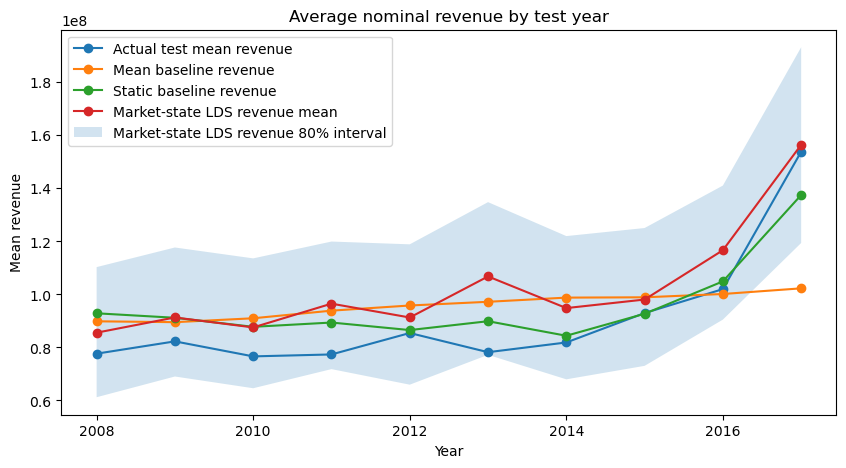

exported rows: 2846
test rows     : 2846
csv path      : ../data/market_state_dynamic_regression_lds_group_nolog_predictions.csv
row order matches test ids: True
min predicted std: 16772541.83243496
max predicted std: 171079139.32595348


,year,actual_mean_revenue,mean_baseline_revenue,static_baseline_revenue,market_lds_revenue_mean,market_lds_revenue_low,market_lds_revenue_high
0,2008,7.765123e+07,8.985532e+07,9.287697e+07,8.556468e+07,6.122052e+07,1.103005e+08
1,2009,8.228889e+07,8.953184e+07,9.118760e+07,9.131090e+07,6.903720e+07,1.177032e+08
2,2010,7.662475e+07,9.100016e+07,8.777484e+07,8.754726e+07,6.461104e+07,1.135948e+08
3,2011,7.735648e+07,9.387577e+07,8.939416e+07,9.651408e+07,7.182152e+07,1.199418e+08
4,2012,8.543854e+07,9.581899e+07,8.655095e+07,9.129362e+07,6.595368e+07,1.188944e+08
5,2013,7.820775e+07,9.721795e+07,8.989163e+07,1.067840e+08,7.720269e+07,1.348079e+08
6,2014,8.187652e+07,9.879288e+07,8.440716e+07,9.484375e+07,6.797170e+07,1.220021e+08
7,2015,9.296569e+07,9.891143e+07,9.270209e+07,9.806743e+07,7.305769e+07,1.250452e+08
8,2016,1.019996e+08,1.001577e+08,1.049162e+08,1.166772e+08,9.049976e+07,1.410620e+08
9,2017,1.538357e+08,1.022911e+08,1.374998e+08,1.564411e+08,1.194032e+08,1.932437e+08


In [8]:
test_ids = test_df["id"].to_numpy()
test_true_revenue = test_df["revenue"].to_numpy()
test_revenue_posterior_samples = test_revenue_samples
predicted_revenue_mean = test_pred_revenue_mean
predicted_revenue_std = test_pred_revenue_std
predicted_revenue_std_safe = np.maximum(predicted_revenue_std, 1e-8)
precision_market_lds = 1.0 / (predicted_revenue_std_safe ** 2)

test_years = np.sort(test_df["year"].unique())
yearly_rows = {year: np.where(test_df["year"].to_numpy() == year)[0] for year in test_years}

summary_rows = []
for year in test_years:
    idx = yearly_rows[year]
    yearly_pred_samples = test_revenue_posterior_samples[:, idx].mean(axis=1)
    summary_rows.append({
        'year': year,
        'actual_mean_revenue': test_df.loc[test_df['year'] == year, 'revenue'].mean(),
        'mean_baseline_revenue': mean_test_pred_revenue[test_df['year'].to_numpy() == year].mean(),
        'static_baseline_revenue': baseline_test_pred_revenue[test_df['year'].to_numpy() == year].mean(),
        'market_lds_revenue_mean': yearly_pred_samples.mean(),
        'market_lds_revenue_low': np.quantile(yearly_pred_samples, 0.1),
        'market_lds_revenue_high': np.quantile(yearly_pred_samples, 0.9),
    })

yearly_test_summary = pd.DataFrame(summary_rows)

plt.figure(figsize=(10, 5))
plt.plot(yearly_test_summary['year'], yearly_test_summary['actual_mean_revenue'], marker='o', label='Actual test mean revenue')
plt.plot(yearly_test_summary['year'], yearly_test_summary['mean_baseline_revenue'], marker='o', label='Mean baseline revenue')
plt.plot(yearly_test_summary['year'], yearly_test_summary['static_baseline_revenue'], marker='o', label='Static baseline revenue')
plt.plot(yearly_test_summary['year'], yearly_test_summary['market_lds_revenue_mean'], marker='o', label='Market-state LDS revenue mean')
plt.fill_between(yearly_test_summary['year'], yearly_test_summary['market_lds_revenue_low'], yearly_test_summary['market_lds_revenue_high'], alpha=0.2, label='Market-state LDS revenue 80% interval')
plt.title('Average nominal revenue by test year')
plt.xlabel('Year')
plt.ylabel('Mean revenue')
plt.legend()
plt.show()

export_columns = {
    'id': test_df['id'].to_numpy(),
    'year': test_df['year'].to_numpy(),
    'revenue': test_true_revenue,
    'predicted_revenue_mean': predicted_revenue_mean,
    'predicted_revenue_std': predicted_revenue_std,
    'precision_market_lds': precision_market_lds,
}
if 'title' in test_df.columns:
    export_columns['title'] = test_df['title'].to_numpy()

export_df = pd.DataFrame(export_columns)
ordered_columns = [c for c in ["id", "title", "year", "revenue", "predicted_revenue_mean", "predicted_revenue_std", "precision_market_lds"] if c in export_df.columns]
export_df = export_df[ordered_columns]
export_df.to_csv(EXPORT_PATH, index=False)

print('exported rows:', len(export_df))
print('test rows     :', len(test_df))
print('csv path      :', EXPORT_PATH)
print('row order matches test ids:', np.array_equal(export_df['id'].to_numpy(), test_df['id'].to_numpy()))
print('min predicted std:', float(predicted_revenue_std.min()))
print('max predicted std:', float(predicted_revenue_std.max()))

yearly_test_summary


## Notes

The model uses weakly informative priors for the global coefficients and scale parameters. The static coefficient vector and the long-run mean of the dynamic coefficients are both given zero-centered Gaussian priors. The market and coefficient transition scales, as well as the observation scale, are given log-normal priors to keep them positive.

The mean-reversion parameters are also learned probabilistically. In the implementation, these are sampled through unconstrained raw variables and mapped through a sigmoid transformation, which keeps the resulting persistence parameters between 0 and 1. This makes the latent dynamics stable while still allowing the data to determine how persistent the yearly states should be.

Finally, the notebook exports predictions on nominal `revenue`, even though the internal model is fitted on `revenue_inflated`.

